# Protein Design Pipeline — Result Analysis

This notebook demonstrates how to parse and analyse outputs from each tool in the protein design pipeline:

1. **RFDiffusion3** — backbone scaffold generation
2. **LigandMPNN** — sequence design (with ligand context)
3. **CARBonAra** — sequence design (structure-conditioned)
4. **AlphaFold3** — structure prediction / validation
5. **Chai-1** — structure prediction / validation
6. **Boltz** — structure prediction / validation

In [1]:
import gzip
import shutil
from pathlib import Path
import gemmi
import pandas as pd
import seaborn as sns

from utils.result_parsers import (
    parse_rfd3_results,
    parse_ligandmpnn_results,
    parse_carbonara_results,
    parse_af3_results,
    parse_chai_results,
    parse_boltz_results,
    merge_results,
)

SAMPLE_DIR = "test_pipeline_results"

## 1. RFDiffusion3 — Scaffold Generation

Parse denoised CIF scaffolds and their metadata (diffused_index_map, rmsd).

In [2]:
# Gunzip all RDF3 files
rfd3_dir = Path(SAMPLE_DIR) / "rfd3"
for gz_file in rfd3_dir.glob("**/*.gz"):
    with gzip.open(gz_file, "rb") as f_in:
        with open(gz_file.with_suffix(""), "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

In [3]:
rfd3_df = parse_rfd3_results(f"{SAMPLE_DIR}/rfd3")
print(f"Parsed {len(rfd3_df)} RFD3 scaffolds")
rfd3_df

Parsed 4 RFD3 scaffolds


,sample_id,structure_file,diffused_index_map,metrics,specification,ckpt_path,seed
0,demo_uncond_monomer_0_model_0,test_pipeline_results/rfd3/demo_uncond_monomer...,{},"{""max_ca_deviation"": 0.08211898803710938, ""n_c...","{""length"": ""80-100"", ""extra"": {""example"": ""unc...",/root/.foundry/checkpoints/rfd3_latest.ckpt,None
1,demo_uncond_monomer_0_model_1,test_pipeline_results/rfd3/demo_uncond_monomer...,{},"{""max_ca_deviation"": 0.09552979469299316, ""n_c...","{""length"": ""80-100"", ""extra"": {""example"": ""unc...",/root/.foundry/checkpoints/rfd3_latest.ckpt,None
2,demo_uncond_monomer_0_model_0,test_pipeline_results/rfd3/demo_uncond_monomer...,{},"{""max_ca_deviation"": 0.08211898803710938, ""n_c...","{""length"": ""80-100"", ""extra"": {""example"": ""unc...",/root/.foundry/checkpoints/rfd3_latest.ckpt,None
3,demo_uncond_monomer_0_model_1,test_pipeline_results/rfd3/demo_uncond_monomer...,{},"{""max_ca_deviation"": 0.09552979469299316, ""n_c...","{""length"": ""80-100"", ""extra"": {""example"": ""unc...",/root/.foundry/checkpoints/rfd3_latest.ckpt,None


In [4]:
#convert the cif files from rfd3 to pdb files using gemmi
for cif_file in rfd3_dir.glob("**/*.cif"):
    structure = gemmi.read_structure(str(cif_file))
    pdb_file = cif_file.with_suffix(".pdb")
    structure.write_pdb(str(pdb_file))

In [5]:
!rsync -avz --progress ./test_pipeline_results/rfd3/*.pdb $USER@jumphost.rcp.epfl.ch:/mnt/hackathon-proteindesign/hackathon-proteindesign-gXX/scratch-gXX/test_pipeline/carbonara/input --exclude='*.cif' --exclude='*.gz'


 ____   ____ ____                _                       _   _           _
|  _ \ / ___|  _ \              | |_   _ _ __ ___  _ __ | | | | ___  ___| |_
| |_) | |   | |_) |  _____   _  | | | | | '_ ` _ \| '_ \| |_| |/ _ \/ __| __|
|  _ <| |___|  __/  |_____| | |_| | |_| | | | | | | |_) |  _  | (_) \__ \ |_
|_| \_\\____|_|              \___/ \__,_|_| |_| |_| .__/|_| |_|\___/|___/\__|
                                                  |_|

sending incremental file list
rsync: [Receiver] mkdir "/mnt/hackathon-proteindesign/hackathon-proteindesign-gXX/scratch-gXX/test_pipeline/carbonara/input" failed: No such file or directory (2)
rsync error: error in file IO (code 11) at main.c(791) [Receiver=3.2.7]


## 2. LigandMPNN — Sequence Design

Parse FASTA outputs with per-sequence confidence and ligand-context scores.

In [6]:
mpnn_df = parse_ligandmpnn_results(f"{SAMPLE_DIR}/ligandmpnn")
print(f"Parsed {len(mpnn_df)} LigandMPNN sequences from {mpnn_df['scaffold_id'].nunique()} scaffolds")
mpnn_df

Parsed 16 LigandMPNN sequences from 2 scaffolds


,id,sequence,scaffold_id,sample_number,overall_confidence,ligand_confidence,seq_recovery
0,demo_uncond_monomer_0_model_0_seq1,MVLRAGDTVTLADGSTRTADAVVDGPLTPEQLEALRAEAAAAGLPE...,demo_uncond_monomer_0_model_0,1,0.4540,0.4540,0.5172
1,demo_uncond_monomer_0_model_0_seq2,AVLKVGDTVTLEDGTTRTVDAVVDGPLTPEEILALREAGRAAGKAE...,demo_uncond_monomer_0_model_0,2,0.4512,0.4512,0.4943
2,demo_uncond_monomer_0_model_0_seq3,CELKVGDTVTFADGSTATADAVVDGELTPEQLLALRAAARAAGKPE...,demo_uncond_monomer_0_model_0,3,0.4547,0.4547,0.5287
3,demo_uncond_monomer_0_model_0_seq4,MTLKAGDTVRLADGSTRTADAVVDGELTPAQLEALRAAAAAAGKPE...,demo_uncond_monomer_0_model_0,4,0.4512,0.4512,0.4943
4,demo_uncond_monomer_0_model_0_seq5,MKLEAGMTLTLEDGERVTVDAVVDGPLTPAELEALRAAARAAGRPR...,demo_uncond_monomer_0_model_0,5,0.4487,0.4487,0.4713
5,demo_uncond_monomer_0_model_0_seq6,MKLEAGMTATLEDGTKVTVDAVVDGPLTPEQLEALRAEAAAAGKAS...,demo_uncond_monomer_0_model_0,6,0.4360,0.4360,0.4483
6,demo_uncond_monomer_0_model_0_seq7,MELRVGMTVTLEDGTTVTVDHVVDGPLTPEQLLALRAEGAAAGKPF...,demo_uncond_monomer_0_model_0,7,0.4493,0.4493,0.4598
7,demo_uncond_monomer_0_model_0_seq8,MELRVGDTVELEDGTRRTVDAVVDGELTPEQLEALRAAAAAAGKPE...,demo_uncond_monomer_0_model_0,8,0.4762,0.4762,0.4713
8,demo_uncond_monomer_0_model_1_seq1,MVEKVIELLENEFNLEVKAIAVDGDTIYVGFKFKEPVEDPEKYIKE...,demo_uncond_monomer_0_model_1,1,0.4059,0.4059,0.4253
9,demo_uncond_monomer_0_model_1_seq2,MLEELIRLLEEEFGLEVQWIAVDGDTIYVGVRFKEPVEDPEAYLKE...,demo_uncond_monomer_0_model_1,2,0.4066,0.4066,0.4253


## 3. CARBonAra — Sequence Design

Parse CARBonAra FASTA outputs (structure-conditioned inverse folding).

In [7]:
carb_df = parse_carbonara_results(f"{SAMPLE_DIR}/carbonara")
print(f"Parsed {len(carb_df)} CARBonAra sequences from {carb_df['scaffold_id'].nunique()} scaffolds")
carb_df

Parsed 2 CARBonAra sequences from 2 scaffolds


,id,sequence,scaffold_id,sample_number,score
0,demo_uncond_monomer_0_model_0_carb0,CKLKEGDTATLDDGTEVIIDAVVNGELSPEQLEEWREEAREAGKPR...,demo_uncond_monomer_0_model_0,0,0.61511
1,demo_uncond_monomer_0_model_1_carb0,MIQKIIELMEKKFNLEVQGIAQDGDTMYVFVQLKTPVPDKEAYLKR...,demo_uncond_monomer_0_model_1,0,0.55511


## 4. AlphaFold3 — Structure Validation

Parse AF3 summary confidences (ptm, iptm, ranking_score, plddt, pae).

In [8]:
af3_df = parse_af3_results(f"{SAMPLE_DIR}/af3")
print(f"Parsed {len(af3_df)} AF3 predictions for {af3_df['id'].nunique()} sequences")
af3_df[["id", "seed", "af3_sample", "ptm", "iptm", "ranking_score", "atom_plddts", "pae"]]

Parsed 8 AF3 predictions for 8 sequences


,id,seed,af3_sample,ptm,iptm,ranking_score,atom_plddts,pae
0,demo_uncond_monomer_0_model_0_seq2,42,2,0.81,NaN,0.81,87.534905,3.608720
1,demo_uncond_monomer_0_model_0_seq3,0,0,0.79,NaN,0.79,88.116100,3.325486
2,demo_uncond_monomer_0_model_0_seq6,42,4,0.78,NaN,0.78,86.260697,3.662928
3,demo_uncond_monomer_0_model_0_seq1,42,2,0.77,NaN,0.77,85.701136,3.869626
4,demo_uncond_monomer_0_model_0_seq5,0,0,0.77,NaN,0.77,85.599529,3.607927
5,demo_uncond_monomer_0_model_0_0,42,2,0.76,NaN,0.76,84.342006,3.861263
6,demo_uncond_monomer_0_model_0_seq4,0,0,0.75,NaN,0.75,84.602279,3.938327
7,demo_uncond_monomer_0_model_0_seq0,0,0,0.67,NaN,0.67,77.213539,5.946928


## 5. Chai-1 — Structure Validation

Parse Chai `.npz` score files. Best (max) score per sequence across model indices.

In [9]:
chai_df = parse_chai_results(f"{SAMPLE_DIR}/chai")
print(f"Parsed {len(chai_df)} Chai predictions")
chai_df

Parsed 3 Chai predictions


,id,aggregate_score,ptm,iptm
0,demo_uncond_monomer_0_model_0_0,0.175102,0.875512,0.0
1,demo_uncond_monomer_0_model_0_seq0,0.133886,0.669430,0.0
2,demo_uncond_monomer_0_model_0_seq1,0.174733,0.873665,0.0


## 6. Boltz — Structure Validation

Parse Boltz confidence JSONs (confidence_score, ptm, iptm, ligand_iptm, complex_plddt).

In [10]:
boltz_df = parse_boltz_results(f"{SAMPLE_DIR}/boltz")
print(f"Parsed {len(boltz_df)} Boltz predictions for {boltz_df['id'].nunique()} sequences")
boltz_df[["id", "confidence_score", "ptm", "iptm", "ligand_iptm", "protein_iptm", "complex_plddt"]]

Parsed 3 Boltz predictions for 3 sequences


,id,confidence_score,ptm,iptm,ligand_iptm,protein_iptm,complex_plddt
0,demo_uncond_monomer_0_model_0_seq1,0.903541,0.873166,0.0,0.0,0.0,0.911135
1,demo_uncond_monomer_0_model_0_0,0.885135,0.840030,0.0,0.0,0.0,0.896412
2,demo_uncond_monomer_0_model_0_seq0,0.805765,0.724011,0.0,0.0,0.0,0.826204


## 7. Merge & Rank

Combine sequence design results with all structure-prediction metrics into a single table.
The `merge_results` function prefixes columns (`af3_`, `chai_`, `boltz_`) and keeps the best prediction per sequence.

In [11]:
import pandas as pd

# Combine LigandMPNN + CARBonAra sequences into one table
# Harmonise column names: CARBonAra uses "score", LigandMPNN uses "overall_confidence"
carb_renamed = carb_df.rename(columns={"score": "overall_confidence"})
carb_renamed["ligand_confidence"] = float("nan")
carb_renamed["seq_recovery"] = float("nan")
carb_renamed["source"] = "carbonara"

mpnn_with_source = mpnn_df.copy()
mpnn_with_source["source"] = "ligand_mpnn"

all_seqs = pd.concat([mpnn_with_source, carb_renamed], ignore_index=True)
print(f"Total designed sequences: {len(all_seqs)} ({len(mpnn_df)} LigandMPNN, {len(carb_df)} CARBonAra)")
all_seqs.head()

Total designed sequences: 18 (16 LigandMPNN, 2 CARBonAra)


,id,sequence,scaffold_id,sample_number,overall_confidence,ligand_confidence,seq_recovery,source
0,demo_uncond_monomer_0_model_0_seq1,MVLRAGDTVTLADGSTRTADAVVDGPLTPEQLEALRAEAAAAGLPE...,demo_uncond_monomer_0_model_0,1,0.4540,0.4540,0.5172,ligand_mpnn
1,demo_uncond_monomer_0_model_0_seq2,AVLKVGDTVTLEDGTTRTVDAVVDGPLTPEEILALREAGRAAGKAE...,demo_uncond_monomer_0_model_0,2,0.4512,0.4512,0.4943,ligand_mpnn
2,demo_uncond_monomer_0_model_0_seq3,CELKVGDTVTFADGSTATADAVVDGELTPEQLLALRAAARAAGKPE...,demo_uncond_monomer_0_model_0,3,0.4547,0.4547,0.5287,ligand_mpnn
3,demo_uncond_monomer_0_model_0_seq4,MTLKAGDTVRLADGSTRTADAVVDGELTPAQLEALRAAAAAAGKPE...,demo_uncond_monomer_0_model_0,4,0.4512,0.4512,0.4943,ligand_mpnn
4,demo_uncond_monomer_0_model_0_seq5,MKLEAGMTLTLEDGERVTVDAVVDGPLTPAELEALRAAARAAGRPR...,demo_uncond_monomer_0_model_0,5,0.4487,0.4487,0.4713,ligand_mpnn


In [12]:
# Merge with all three structure-prediction tools
merged = merge_results(all_seqs, af3_df=af3_df, chai_df=chai_df, boltz_df=boltz_df)
print(f"Merged table: {len(merged)} rows x {len(merged.columns)} columns")
merged.head()

Merged table: 18 rows x 30 columns


,id,sequence,scaffold_id,sample_number,overall_confidence,ligand_confidence,seq_recovery,source,af3_seed,af3_af3_sample,...,chai_ptm,chai_iptm,boltz_confidence_score,boltz_ptm,boltz_iptm,boltz_ligand_iptm,boltz_protein_iptm,boltz_complex_plddt,boltz_complex_iplddt,boltz_model_path
0,demo_uncond_monomer_0_model_0_seq1,MVLRAGDTVTLADGSTRTADAVVDGPLTPEQLEALRAEAAAAGLPE...,demo_uncond_monomer_0_model_0,1,0.4540,0.4540,0.5172,ligand_mpnn,42.0,2.0,...,0.873665,0.0,0.903541,0.873166,0.0,0.0,0.0,0.911135,0.911135,test_pipeline_results/boltz/demo_uncond_monome...
1,demo_uncond_monomer_0_model_0_seq2,AVLKVGDTVTLEDGTTRTVDAVVDGPLTPEEILALREAGRAAGKAE...,demo_uncond_monomer_0_model_0,2,0.4512,0.4512,0.4943,ligand_mpnn,42.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,demo_uncond_monomer_0_model_0_seq3,CELKVGDTVTFADGSTATADAVVDGELTPEQLLALRAAARAAGKPE...,demo_uncond_monomer_0_model_0,3,0.4547,0.4547,0.5287,ligand_mpnn,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,demo_uncond_monomer_0_model_0_seq4,MTLKAGDTVRLADGSTRTADAVVDGELTPAQLEALRAAAAAAGKPE...,demo_uncond_monomer_0_model_0,4,0.4512,0.4512,0.4943,ligand_mpnn,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,demo_uncond_monomer_0_model_0_seq5,MKLEAGMTLTLEDGERVTVDAVVDGPLTPAELEALRAAARAAGRPR...,demo_uncond_monomer_0_model_0,5,0.4487,0.4487,0.4713,ligand_mpnn,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Rank by AF3 ranking_score (descending)
ranked = merged.sort_values("af3_ranking_score", ascending=False).reset_index(drop=True)
ranked[["id", "scaffold_id", "source", "af3_ranking_score", "af3_iptm", "chai_aggregate_score", "boltz_confidence_score"]].head(10)

,id,scaffold_id,source,af3_ranking_score,af3_iptm,chai_aggregate_score,boltz_confidence_score
0,demo_uncond_monomer_0_model_0_seq2,demo_uncond_monomer_0_model_0,ligand_mpnn,0.81,NaN,NaN,NaN
1,demo_uncond_monomer_0_model_0_seq3,demo_uncond_monomer_0_model_0,ligand_mpnn,0.79,NaN,NaN,NaN
2,demo_uncond_monomer_0_model_0_seq6,demo_uncond_monomer_0_model_0,ligand_mpnn,0.78,NaN,NaN,NaN
3,demo_uncond_monomer_0_model_0_seq1,demo_uncond_monomer_0_model_0,ligand_mpnn,0.77,NaN,0.174733,0.903541
4,demo_uncond_monomer_0_model_0_seq5,demo_uncond_monomer_0_model_0,ligand_mpnn,0.77,NaN,NaN,NaN
5,demo_uncond_monomer_0_model_0_seq4,demo_uncond_monomer_0_model_0,ligand_mpnn,0.75,NaN,NaN,NaN
6,demo_uncond_monomer_0_model_0_seq7,demo_uncond_monomer_0_model_0,ligand_mpnn,NaN,NaN,NaN,NaN
7,demo_uncond_monomer_0_model_0_seq8,demo_uncond_monomer_0_model_0,ligand_mpnn,NaN,NaN,NaN,NaN
8,demo_uncond_monomer_0_model_1_seq1,demo_uncond_monomer_0_model_1,ligand_mpnn,NaN,NaN,NaN,NaN
9,demo_uncond_monomer_0_model_1_seq2,demo_uncond_monomer_0_model_1,ligand_mpnn,NaN,NaN,NaN,NaN


## 8. Compute Cα RMSD (RFD3 design vs AF3 prediction)

For each design with an AF3 model, compute the global Cα RMSD between the original RFD3 scaffold and the AF3-predicted structure. Low RMSD means AF3 recapitulates the designed fold.

In [14]:
import numpy as np

def _kabsch_rmsd(P, Q):
    """Kabsch-aligned Cα RMSD between two Nx3 coordinate arrays."""
    P = P - P.mean(axis=0)
    Q = Q - Q.mean(axis=0)
    H = P.T @ Q
    U, S, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    D = np.diag([1, 1, d])
    R = Vt.T @ D @ U.T
    P_rot = P @ R.T
    return float(np.sqrt(np.mean(np.sum((P_rot - Q) ** 2, axis=1))))

def compute_ca_rmsd(designed_path, af3_cif_path):
    """Global Cα RMSD between RFD3 designed backbone and AF3 prediction."""
    des = gemmi.read_structure(str(designed_path))
    af3 = gemmi.read_structure(str(af3_cif_path))

    des_ca = []
    for res in des[0][0]:
        ca = res.find_atom("CA", "\0")
        if ca:
            des_ca.append([ca.pos.x, ca.pos.y, ca.pos.z])

    af3_ca = []
    for chain in af3[0]:
        for res in chain:
            ca = res.find_atom("CA", "\0")
            if ca:
                af3_ca.append([ca.pos.x, ca.pos.y, ca.pos.z])
        break  # first chain only (protein chain A)

    if not des_ca or not af3_ca:
        return np.nan

    n = min(len(des_ca), len(af3_ca))
    return _kabsch_rmsd(np.array(des_ca[:n]), np.array(af3_ca[:n]))

# Map scaffold_id -> RFD3 structure file from rfd3_df
scaffold_to_file = {}
for _, row in rfd3_df.iterrows():
    scaffold_to_file[row['sample_id']] = row['structure_file']

# Compute Cα RMSD for each design
ca_rmsds = []
for _, row in ranked.iterrows():
    af3_model = row.get('af3_model_path', '')
    scaffold_id = row.get('scaffold_id', '')
    design_file = scaffold_to_file.get(scaffold_id, '')

    if (isinstance(af3_model, str) and af3_model
            and isinstance(design_file, str) and design_file
            and Path(af3_model).exists() and Path(design_file).exists()):
        try:
            ca_rmsds.append(compute_ca_rmsd(design_file, af3_model))
        except Exception as e:
            print(f"  RMSD error for {row['id']}: {e}")
            ca_rmsds.append(np.nan)
    else:
        ca_rmsds.append(np.nan)

ranked['ca_rmsd'] = ca_rmsds
valid = ranked['ca_rmsd'].notna().sum()
print(f"Computed Cα RMSD for {valid}/{len(ranked)} designs")
if valid > 0:
    print(f"  Range: {ranked['ca_rmsd'].min():.2f} – {ranked['ca_rmsd'].max():.2f} Å")
ranked[['id', 'scaffold_id', 'ca_rmsd', 'af3_ranking_score']].head(10)

Computed Cα RMSD for 6/18 designs
  Range: 0.48 – 1.86 Å


,id,scaffold_id,ca_rmsd,af3_ranking_score
0,demo_uncond_monomer_0_model_0_seq2,demo_uncond_monomer_0_model_0,1.237433,0.81
1,demo_uncond_monomer_0_model_0_seq3,demo_uncond_monomer_0_model_0,0.585504,0.79
2,demo_uncond_monomer_0_model_0_seq6,demo_uncond_monomer_0_model_0,0.758298,0.78
3,demo_uncond_monomer_0_model_0_seq1,demo_uncond_monomer_0_model_0,0.566047,0.77
4,demo_uncond_monomer_0_model_0_seq5,demo_uncond_monomer_0_model_0,1.857534,0.77
5,demo_uncond_monomer_0_model_0_seq4,demo_uncond_monomer_0_model_0,0.483781,0.75
6,demo_uncond_monomer_0_model_0_seq7,demo_uncond_monomer_0_model_0,NaN,NaN
7,demo_uncond_monomer_0_model_0_seq8,demo_uncond_monomer_0_model_0,NaN,NaN
8,demo_uncond_monomer_0_model_1_seq1,demo_uncond_monomer_0_model_1,NaN,NaN
9,demo_uncond_monomer_0_model_1_seq2,demo_uncond_monomer_0_model_1,NaN,NaN


## 9. ipSAE — Interface Predicted Structural Alignment Error

Compute the **ipSAE** score for each AF3 prediction. ipSAE is an interface-specific metric
derived from PAE (Predicted Aligned Error) matrices, developed by
[Roland Dunbrack, Fox Chase Cancer Center](https://www.biorxiv.org/content/10.1101/2025.02.10.637595v1).

The ipSAE score evaluates pairwise protein–protein (or protein–ligand) interactions
using PAE values with a cutoff, and a TM-score-like normalization. It also computes
pDockQ, pDockQ2, and LIS as complementary interface quality metrics.

**Implementation adapted from `ligand-binder-pipeline/src/ipsae.py` (Dunbrack lab, v3, April 2025, MIT license).**

In [15]:
import json
import math

# ---------------------------------------------------------------------------
# ipSAE core functions — adapted from Dunbrack lab ipsae.py (v3, April 2025)
# https://www.biorxiv.org/content/10.1101/2025.02.10.637595v1
# Roland Dunbrack, Fox Chase Cancer Center — MIT license
# ---------------------------------------------------------------------------

def _ptm_func(x, d0):
    return 1.0 / (1.0 + (x / d0) ** 2.0)

_ptm_func_vec = np.vectorize(_ptm_func)

def _calc_d0(L):
    L = float(max(L, 27))
    return max(1.0, 1.24 * (L - 15) ** (1.0 / 3.0) - 1.8)

def _parse_af3_cif_for_ipsae(cif_path):
    """Parse an AF3 mmCIF file to extract CA/CB coordinates, chains, residue info, and token mask."""
    st = gemmi.read_structure(str(cif_path))
    model = st[0]

    residues_ca = []
    residues_cb = []
    chains = []
    ca_atom_nums = []
    cb_atom_nums = []

    atom_idx = 0
    token_mask = []

    residue_set = {
        "ALA", "ARG", "ASN", "ASP", "CYS", "GLN", "GLU", "GLY", "HIS", "ILE",
        "LEU", "LYS", "MET", "PHE", "PRO", "SER", "THR", "TRP", "TYR", "VAL",
        "DA", "DC", "DT", "DG", "A", "C", "U", "G",
    }

    for chain in model:
        for res in chain:
            for atom in res:
                is_ca = atom.name == "CA"
                is_cb = atom.name == "CB" or (res.name == "GLY" and atom.name == "CA")
                is_standard = res.name in residue_set

                if is_ca and is_standard:
                    token_mask.append(1)
                    ca_atom_nums.append(atom_idx)
                    residues_ca.append({
                        'coor': np.array([atom.pos.x, atom.pos.y, atom.pos.z]),
                        'res': res.name,
                        'chainid': chain.name,
                        'resnum': res.seqid.num,
                    })
                    chains.append(chain.name)
                elif not is_ca and not is_standard:
                    token_mask.append(0)

                if is_cb:
                    cb_atom_nums.append(atom_idx)
                    residues_cb.append({
                        'coor': np.array([atom.pos.x, atom.pos.y, atom.pos.z]),
                        'res': res.name,
                        'chainid': chain.name,
                        'resnum': res.seqid.num,
                    })

                atom_idx += 1

    return residues_ca, residues_cb, chains, ca_atom_nums, cb_atom_nums, token_mask


def compute_ipsae_from_af3(confidences_json_path, cif_path, pae_cutoff=10.0, dist_cutoff=10.0):
    """Compute ipSAE, pDockQ, pDockQ2, and LIS for an AF3 prediction.

    Returns a dict with per-chain-pair metrics (max over chain pair directions).
    For single-chain monomers, returns empty metrics.
    """
    residues_ca, residues_cb, chains_list, ca_atom_nums, cb_atom_nums, token_mask = \
        _parse_af3_cif_for_ipsae(cif_path)

    if not residues_ca:
        return {}

    # Load AF3 confidences
    with open(str(confidences_json_path)) as f:
        data = json.load(f)

    atom_plddts = np.array(data['atom_plddts'])
    plddt = atom_plddts[ca_atom_nums]
    cb_plddt = atom_plddts[cb_atom_nums] if cb_atom_nums else plddt

    if 'pae' not in data:
        return {}

    pae_full = np.array(data['pae'])
    token_array = np.array(token_mask)
    pae_matrix = pae_full[np.ix_(token_array.astype(bool), token_array.astype(bool))]

    numres = len(residues_ca)
    chains = np.array(chains_list)
    unique_chains = np.unique(chains)

    if len(unique_chains) < 2:
        return {}  # monomer — no interchain metrics

    # CB coordinates for distance matrix
    cb_coords = np.array([r['coor'] for r in residues_cb])
    if len(cb_coords) != numres:
        cb_coords = np.array([r['coor'] for r in residues_ca])
    distances = np.sqrt(((cb_coords[:, None, :] - cb_coords[None, :, :]) ** 2).sum(axis=2))

    results = {}

    for chain1 in unique_chains:
        for chain2 in unique_chains:
            if chain1 >= chain2:
                continue

            pair_key = f"{chain1}-{chain2}"

            # n0chn and d0
            n0 = int(np.sum(chains == chain1) + np.sum(chains == chain2))
            d0 = _calc_d0(n0)

            # --- ipSAE (d0chn) ---
            ipsae_vals = []
            for direction in [(chain1, chain2), (chain2, chain1)]:
                c1, c2 = direction
                vals = []
                for i in range(numres):
                    if chains[i] != c1:
                        continue
                    valid = (chains == c2) & (pae_matrix[i] < pae_cutoff)
                    if valid.any():
                        ptm_row = _ptm_func_vec(pae_matrix[i], d0)
                        vals.append(ptm_row[valid].mean())
                ipsae_vals.append(max(vals) if vals else 0.0)
            ipsae_max = max(ipsae_vals)

            # --- pDockQ ---
            pdockq_cutoff = 8.0
            npairs = 0
            contact_residues = set()
            for i in range(numres):
                if chains[i] not in (chain1, chain2):
                    continue
                other = chain2 if chains[i] == chain1 else chain1
                valid = (chains == other) & (distances[i] <= pdockq_cutoff)
                n = int(np.sum(valid))
                npairs += n
                if n > 0:
                    contact_residues.add(i)
                    contact_residues.update(np.where(valid)[0].tolist())

            if npairs > 0 and contact_residues:
                mean_plddt_val = cb_plddt[list(contact_residues)].mean()
                x = mean_plddt_val * math.log10(npairs)
                pdockq = 0.724 / (1 + math.exp(-0.052 * (x - 152.611))) + 0.018
            else:
                pdockq = 0.0

            # --- pDockQ2 ---
            npairs2 = 0
            ptm_sum = 0.0
            for c1, c2 in [(chain1, chain2), (chain2, chain1)]:
                for i in range(numres):
                    if chains[i] != c1:
                        continue
                    valid = (chains == c2) & (distances[i] <= pdockq_cutoff)
                    if valid.any():
                        npairs2 += int(np.sum(valid))
                        ptm_sum += _ptm_func_vec(pae_matrix[i][valid], 10.0).sum()

            if npairs2 > 0 and contact_residues:
                mean_plddt_val = cb_plddt[list(contact_residues)].mean()
                mean_ptm = ptm_sum / npairs2
                x = mean_plddt_val * mean_ptm
                pdockq2 = 1.31 / (1 + math.exp(-0.075 * (x - 84.733))) + 0.005
            else:
                pdockq2 = 0.0

            # --- LIS ---
            lis_scores = []
            for c1, c2 in [(chain1, chain2), (chain2, chain1)]:
                mask = (chains[:, None] == c1) & (chains[None, :] == c2)
                selected_pae = pae_matrix[mask]
                if selected_pae.size > 0:
                    valid_pae = selected_pae[selected_pae <= 12]
                    if valid_pae.size > 0:
                        lis_scores.append(np.mean((12 - valid_pae) / 12))
                    else:
                        lis_scores.append(0.0)
                else:
                    lis_scores.append(0.0)
            lis = np.mean(lis_scores)

            results[pair_key] = {
                'ipsae': ipsae_max,
                'pdockq': pdockq,
                'pdockq2': pdockq2,
                'lis': lis,
            }

    return results


# Compute ipSAE for each AF3 prediction in the ranked table
ipsae_scores = []
pdockq_scores = []
pdockq2_scores = []
lis_scores = []

for _, row in ranked.iterrows():
    af3_model = row.get('af3_model_path', '')
    if not isinstance(af3_model, str) or not af3_model or not Path(af3_model).exists():
        ipsae_scores.append(np.nan)
        pdockq_scores.append(np.nan)
        pdockq2_scores.append(np.nan)
        lis_scores.append(np.nan)
        continue

    # Find the confidences JSON (same directory as model CIF)
    model_path = Path(af3_model)
    prefix = model_path.name.replace('_model.cif', '')
    conf_path = model_path.parent / f"{prefix}_confidences.json"

    if not conf_path.exists():
        ipsae_scores.append(np.nan)
        pdockq_scores.append(np.nan)
        pdockq2_scores.append(np.nan)
        lis_scores.append(np.nan)
        continue

    try:
        result = compute_ipsae_from_af3(conf_path, model_path)
        if result:
            # Take the best (max) ipSAE across all chain pairs
            best = max(result.values(), key=lambda x: x['ipsae'])
            ipsae_scores.append(best['ipsae'])
            pdockq_scores.append(best['pdockq'])
            pdockq2_scores.append(best['pdockq2'])
            lis_scores.append(best['lis'])
        else:
            # Monomer — no interchain metrics
            ipsae_scores.append(np.nan)
            pdockq_scores.append(np.nan)
            pdockq2_scores.append(np.nan)
            lis_scores.append(np.nan)
    except Exception as e:
        print(f"  ipSAE error for {row['id']}: {e}")
        ipsae_scores.append(np.nan)
        pdockq_scores.append(np.nan)
        pdockq2_scores.append(np.nan)
        lis_scores.append(np.nan)

ranked['ipsae'] = ipsae_scores
ranked['pdockq'] = pdockq_scores
ranked['pdockq2'] = pdockq2_scores
ranked['lis'] = lis_scores

valid = ranked['ipsae'].notna().sum()
print(f"Computed ipSAE (Dunbrack) for {valid}/{len(ranked)} designs")
if valid > 0:
    print(f"  ipSAE range: {ranked['ipsae'].min():.4f} – {ranked['ipsae'].max():.4f}")
    print(f"  pDockQ range: {ranked['pdockq'].min():.4f} – {ranked['pdockq'].max():.4f}")
    print(f"  pDockQ2 range: {ranked['pdockq2'].min():.4f} – {ranked['pdockq2'].max():.4f}")
    print(f"  LIS range: {ranked['lis'].min():.4f} – {ranked['lis'].max():.4f}")
else:
    print("  (No multi-chain AF3 predictions found — ipSAE requires interchain contacts)")
ranked[['id', 'ipsae', 'pdockq', 'pdockq2', 'lis']].head(10)

Computed ipSAE (Dunbrack) for 0/18 designs
  (No multi-chain AF3 predictions found — ipSAE requires interchain contacts)


,id,ipsae,pdockq,pdockq2,lis
0,demo_uncond_monomer_0_model_0_seq2,NaN,NaN,NaN,NaN
1,demo_uncond_monomer_0_model_0_seq3,NaN,NaN,NaN,NaN
2,demo_uncond_monomer_0_model_0_seq6,NaN,NaN,NaN,NaN
3,demo_uncond_monomer_0_model_0_seq1,NaN,NaN,NaN,NaN
4,demo_uncond_monomer_0_model_0_seq5,NaN,NaN,NaN,NaN
5,demo_uncond_monomer_0_model_0_seq4,NaN,NaN,NaN,NaN
6,demo_uncond_monomer_0_model_0_seq7,NaN,NaN,NaN,NaN
7,demo_uncond_monomer_0_model_0_seq8,NaN,NaN,NaN,NaN
8,demo_uncond_monomer_0_model_1_seq1,NaN,NaN,NaN,NaN
9,demo_uncond_monomer_0_model_1_seq2,NaN,NaN,NaN,NaN


## 10. Pairwise Metric Scatter Plots

Visualize all available validation metrics in a pairwise scatter plot.
Background colors indicate the source model (AF3, Chai, Boltz). Arrows indicate metric direction.

Plotting 13 metrics: ['chai_aggregate_score', 'chai_ptm', 'chai_iptm', 'boltz_confidence_score', 'boltz_ptm', 'boltz_ligand_iptm', 'boltz_protein_iptm', 'boltz_complex_iplddt', 'af3_pae', 'af3_ranking_score', 'af3_ptm', 'af3_atom_plddts', 'ca_rmsd']


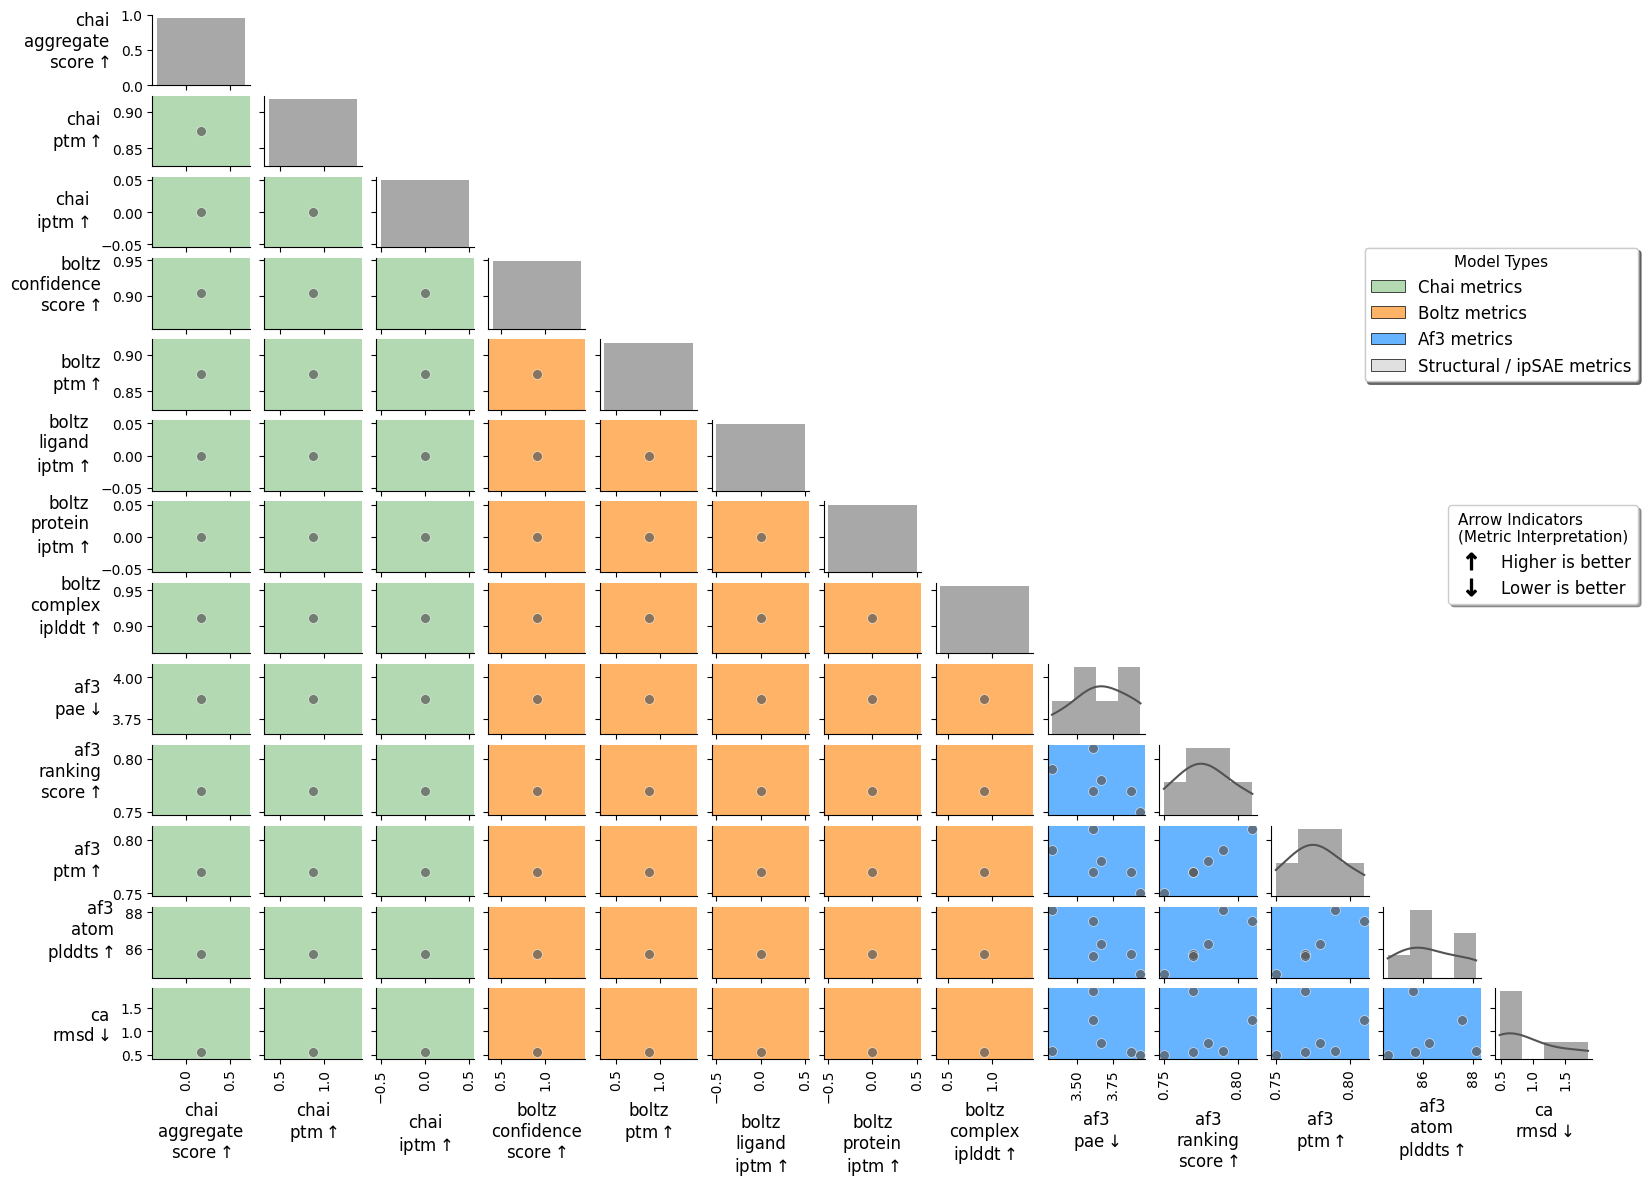

Saved to plots/scatterplot_all_metrics.png


In [16]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

# ---------------------------------------------------------------------------
# Helper: infer model from metric column name
# ---------------------------------------------------------------------------
def get_model_from_metric(metric_name):
    if metric_name.startswith('af3'):
        return 'af3'
    elif metric_name.startswith('chai'):
        return 'chai'
    elif metric_name.startswith('boltz'):
        return 'boltz'
    else:
        return 'unknown'

# ---------------------------------------------------------------------------
# Build metric list from columns actually present in ranked
# ---------------------------------------------------------------------------
_candidate_metrics = [
    # Chai metrics
    'chai_aggregate_score', 'chai_ptm', 'chai_iptm',
    # Boltz metrics
    'boltz_confidence_score', 'boltz_ptm', 'boltz_ligand_iptm',
    'boltz_protein_iptm', 'boltz_complex_iplddt',
    # AF3 metrics
    'af3_pae', 'af3_ranking_score', 'af3_ptm', 'af3_iptm', 'af3_atom_plddts',
    # Structural metrics
    'ca_rmsd',
    # ipSAE metrics (Dunbrack lab)
    'ipsae', 'pdockq', 'pdockq2', 'lis',
]

metrics = [m for m in _candidate_metrics
           if m in ranked.columns and ranked[m].notna().sum() > 0]

print(f"Plotting {len(metrics)} metrics: {metrics}")

# Metric directions (higher/lower is better)
metric_directions = {
    'chai_aggregate_score': 'higher',
    'chai_ptm': 'higher',
    'chai_iptm': 'higher',
    'boltz_confidence_score': 'higher',
    'boltz_ptm': 'higher',
    'boltz_ligand_iptm': 'higher',
    'boltz_protein_iptm': 'higher',
    'boltz_complex_iplddt': 'higher',
    'af3_pae': 'lower',
    'af3_ranking_score': 'higher',
    'af3_ptm': 'higher',
    'af3_iptm': 'higher',
    'af3_atom_plddts': 'higher',
    'ca_rmsd': 'lower',
    'ipsae': 'higher',
    'pdockq': 'higher',
    'pdockq2': 'higher',
    'lis': 'higher',
}

# Background colors per model
background_colors = {
    'chai': '#b3d9b3',     # Green
    'boltz': '#ffb366',    # Orange
    'af3': '#66b3ff',      # Blue
    'unknown': '#e0e0e0',  # Gray (structural / ipSAE metrics)
}

def enhanced_scatter_with_bg(x, y, **kwargs):
    ax = plt.gca()
    x_model = get_model_from_metric(x.name)
    bg_color = background_colors.get(x_model, background_colors['unknown'])
    ax.set_facecolor(bg_color)
    ax.scatter(x=x, y=y, color="#585858", s=50, alpha=0.7,
               edgecolor='white', linewidth=0.5)

# Create PairGrid
g = sns.PairGrid(ranked, vars=metrics, diag_sharey=False)
g.map_lower(enhanced_scatter_with_bg)
g.map_diag(sns.histplot, kde=True, alpha=0.5, linewidth=0, color="#535353")

# Hide upper triangle
for i in range(len(metrics)):
    for j in range(i + 1, len(metrics)):
        if i < len(g.axes) and j < len(g.axes[i]) and g.axes[i][j]:
            g.axes[i][j].set_visible(False)

# Formatting
for ax in g.axes.flatten():
    if ax and ax.get_visible():
        if ax.get_xlabel():
            xlabel = ax.get_xlabel().replace('_', '\n')
            direction = metric_directions.get(ax.get_xlabel(), 'unknown')
            if direction == 'higher':
                xlabel += '$\\uparrow$'
            elif direction == 'lower':
                xlabel += '$\\downarrow$'
            ax.set_xlabel(xlabel, fontsize=12, labelpad=8)
        if ax.get_ylabel():
            ylabel = ax.get_ylabel().replace('_', '\n')
            direction = metric_directions.get(ax.get_ylabel(), 'unknown')
            if direction == 'higher':
                ylabel += '$\\uparrow$'
            elif direction == 'lower':
                ylabel += '$\\downarrow$'
            ax.set_ylabel(ylabel, fontsize=12, labelpad=8)
            ax.yaxis.label.set_rotation(0)
            ax.yaxis.label.set_position((-0.6, 0.2))
            ax.yaxis.label.set_horizontalalignment('right')
        ax.tick_params(axis='x', rotation=90)

g.figure.set_size_inches(18, 12)
plt.subplots_adjust(top=0.95, bottom=0.08, left=0.15, right=0.95,
                    hspace=0.15, wspace=0.15)

# Legends — only include models that have metrics in the plot
models_in_plot = set(get_model_from_metric(m) for m in metrics)
bg_legend = [plt.Rectangle((0, 0), 1, 1, facecolor=c, edgecolor='black',
             linewidth=0.5, label=f'{m[0].upper()+m[1:]} metrics')
             for m, c in background_colors.items() if m != 'unknown' and m in models_in_plot]
if 'unknown' in models_in_plot:
    bg_legend.append(plt.Rectangle((0, 0), 1, 1, facecolor='#e0e0e0', edgecolor='black',
                     linewidth=0.5, label='Structural / ipSAE metrics'))
arrow_legend = [
    plt.Line2D([0], [0], marker='$\\uparrow$', color='black', linestyle='None',
               markersize=12, label='Higher is better'),
    plt.Line2D([0], [0], marker='$\\downarrow$', color='black', linestyle='None',
               markersize=12, label='Lower is better'),
]

legend1 = g.figure.legend(handles=bg_legend, title='Model Types',
                          loc='center right', bbox_to_anchor=(0.98, 0.7),
                          fontsize=12, title_fontsize=11, frameon=True,
                          fancybox=True, shadow=True)
legend2 = g.figure.legend(handles=arrow_legend,
                          title='Arrow Indicators\n(Metric Interpretation)',
                          loc='center right', bbox_to_anchor=(0.98, 0.5),
                          fontsize=12, title_fontsize=11, frameon=True,
                          fancybox=True, shadow=True)
g.figure.add_artist(legend1)

os.makedirs("plots", exist_ok=True)
plt.savefig("plots/scatterplot_all_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/scatterplot_all_metrics.png")

## 11. Selection Scatter Plot

Highlight the filtered designs (red) against all designs (gray) on the key filtering metrics.

Selected designs: 0 / 18
Selection plot metrics: ['af3_ptm', 'af3_ranking_score', 'chai_iptm', 'chai_aggregate_score', 'boltz_confidence_score', 'boltz_ligand_iptm', 'ca_rmsd']


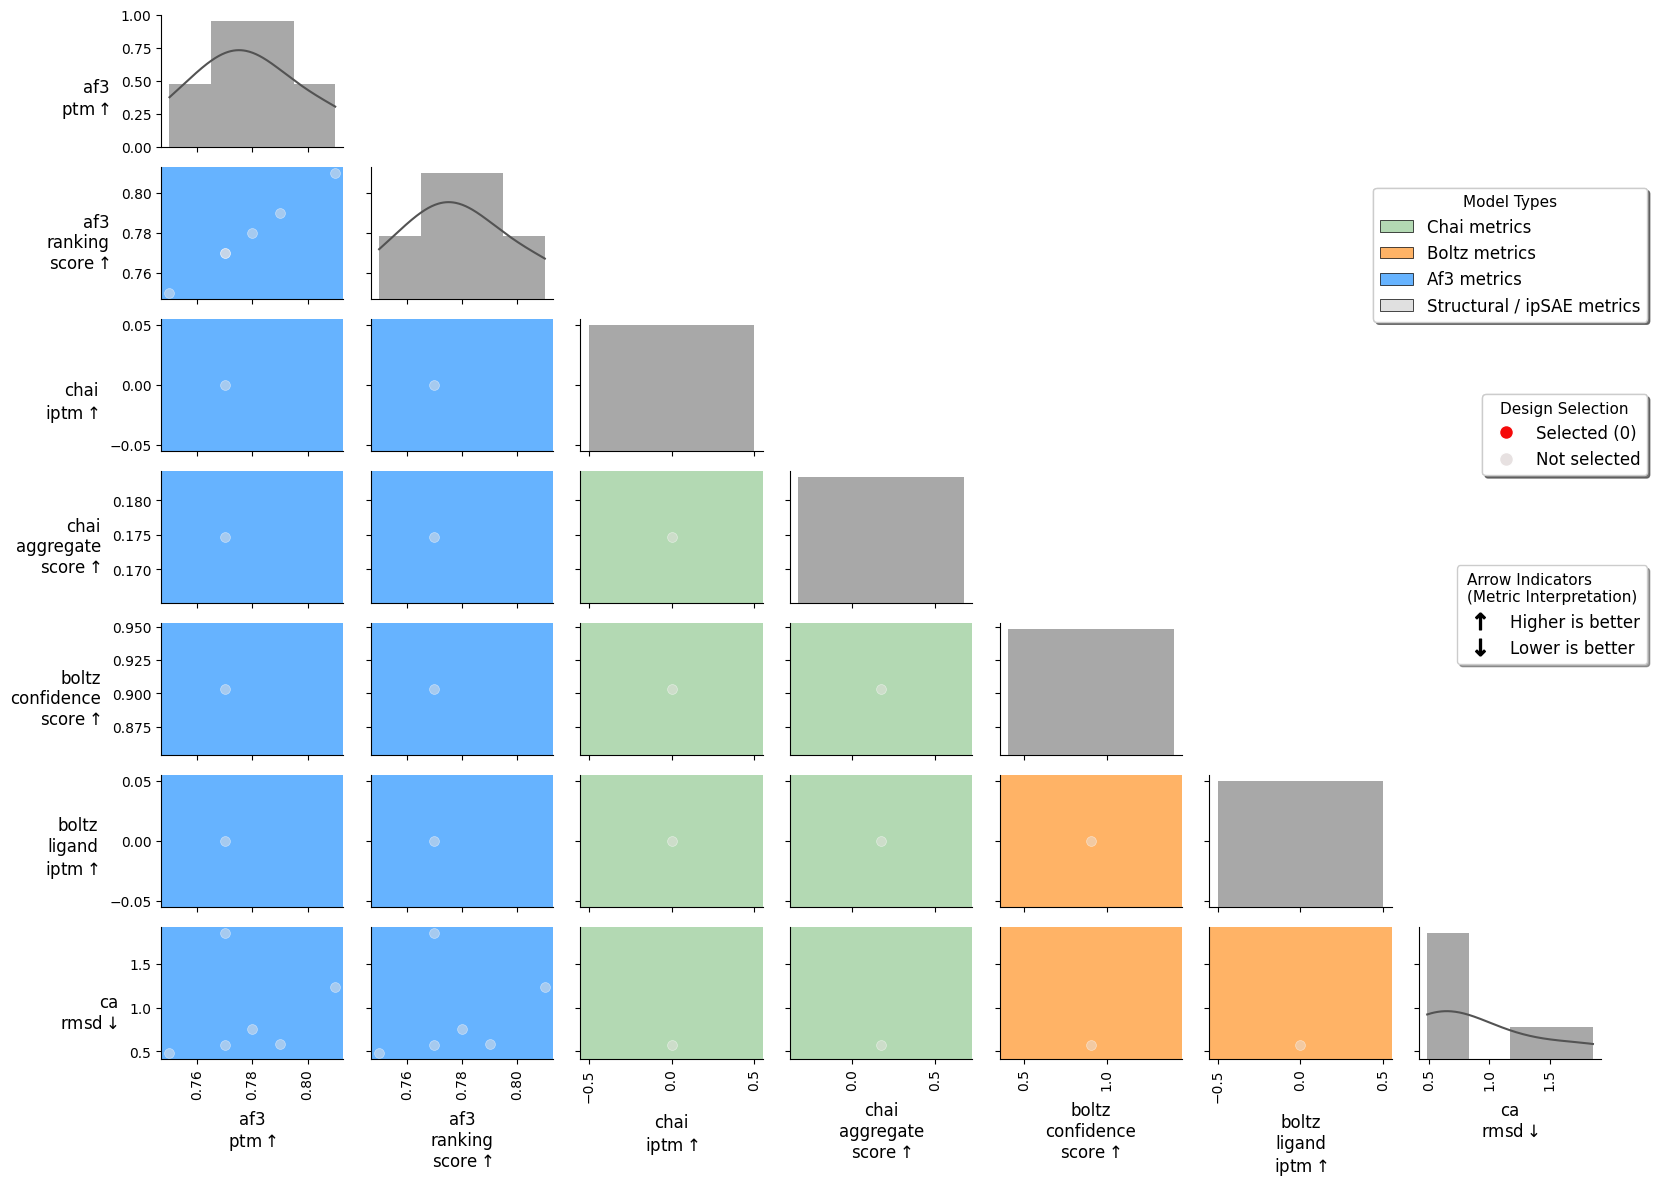

Saved to plots/scatterplot_selection.png


In [17]:
# Apply filter inline for the selection plot
_filtered_for_plot = ranked.dropna(subset=["af3_ranking_score", "chai_aggregate_score"])
_filtered_for_plot = _filtered_for_plot[
    (_filtered_for_plot["af3_ranking_score"] > 0.6)
    & (_filtered_for_plot["chai_aggregate_score"] > 0.7)
]

# Build selection mask: mark filtered designs in the full dataframe
ranked['selected'] = ranked['id'].isin(_filtered_for_plot['id'])
print(f"Selected designs: {ranked['selected'].sum()} / {len(ranked)}")

# Key metrics for selection plot
_candidate_selection_metrics = [
    'af3_ptm', 'af3_iptm', 'af3_ranking_score',
    'chai_iptm', 'chai_aggregate_score',
    'boltz_confidence_score', 'boltz_ligand_iptm',
    'ca_rmsd', 'ipsae', 'pdockq2',
]
selection_metrics = [m for m in _candidate_selection_metrics
                     if m in ranked.columns and ranked[m].notna().sum() > 0]

print(f"Selection plot metrics: {selection_metrics}")

df_plot = ranked.copy()

def enhanced_scatter_with_bg_selected(x, y, **kwargs):
    ax = plt.gca()
    x_model = get_model_from_metric(x.name)
    bg_color = background_colors.get(x_model, background_colors['unknown'])
    ax.set_facecolor(bg_color)

    selected_mask = df_plot['selected']
    # Non-selected: translucent gray
    ax.scatter(x[~selected_mask], y[~selected_mask], color="#E7E1E1",
               s=50, alpha=0.5, edgecolor='white', linewidth=0.5)
    # Selected: red
    ax.scatter(x[selected_mask], y[selected_mask], color="#F50A0A",
               s=50, alpha=0.7, edgecolor='white', linewidth=0.5)

g = sns.PairGrid(df_plot, vars=selection_metrics, diag_sharey=False)
g.map_lower(enhanced_scatter_with_bg_selected)
g.map_diag(sns.histplot, kde=True, alpha=0.5, linewidth=0, color="#535353")

# Hide upper triangle
for i in range(len(selection_metrics)):
    for j in range(i + 1, len(selection_metrics)):
        if i < len(g.axes) and j < len(g.axes[i]) and g.axes[i][j]:
            g.axes[i][j].set_visible(False)

# Formatting
for ax in g.axes.flatten():
    if ax and ax.get_visible():
        if ax.get_xlabel():
            xlabel = ax.get_xlabel().replace('_', '\n')
            direction = metric_directions.get(ax.get_xlabel(), 'unknown')
            if direction == 'higher':
                xlabel += '$\\uparrow$'
            elif direction == 'lower':
                xlabel += '$\\downarrow$'
            ax.set_xlabel(xlabel, fontsize=12, labelpad=8)
        if ax.get_ylabel():
            ylabel = ax.get_ylabel().replace('_', '\n')
            direction = metric_directions.get(ax.get_ylabel(), 'unknown')
            if direction == 'higher':
                ylabel += '$\\uparrow$'
            elif direction == 'lower':
                ylabel += '$\\downarrow$'
            ax.set_ylabel(ylabel, fontsize=12, labelpad=8)
            ax.yaxis.label.set_rotation(0)
            ax.yaxis.label.set_position((-0.6, 0.2))
            ax.yaxis.label.set_horizontalalignment('right')
        ax.tick_params(axis='x', rotation=90)

g.figure.set_size_inches(18, 12)
plt.subplots_adjust(top=0.95, bottom=0.08, left=0.15, right=0.95,
                    hspace=0.15, wspace=0.15)

# Legends
models_in_selection = set(get_model_from_metric(m) for m in selection_metrics)
bg_legend = [plt.Rectangle((0, 0), 1, 1, facecolor=c, edgecolor='black',
             linewidth=0.5, label=f'{m[0].upper()+m[1:]} metrics')
             for m, c in background_colors.items() if m != 'unknown' and m in models_in_selection]
if 'unknown' in models_in_selection:
    bg_legend.append(plt.Rectangle((0, 0), 1, 1, facecolor='#e0e0e0', edgecolor='black',
                     linewidth=0.5, label='Structural / ipSAE metrics'))
n_selected = int(ranked['selected'].sum())
selection_legend = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#F50A0A',
               markersize=10, label=f'Selected ({n_selected})'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#E7E1E1',
               markersize=10, label='Not selected'),
]
arrow_legend = [
    plt.Line2D([0], [0], marker='$\\uparrow$', color='black', linestyle='None',
               markersize=12, label='Higher is better'),
    plt.Line2D([0], [0], marker='$\\downarrow$', color='black', linestyle='None',
               markersize=12, label='Lower is better'),
]

legend1 = g.figure.legend(handles=bg_legend, title='Model Types',
                          loc='center right', bbox_to_anchor=(0.98, 0.75),
                          fontsize=12, title_fontsize=11, frameon=True,
                          fancybox=True, shadow=True)
legend2 = g.figure.legend(handles=selection_legend, title='Design Selection',
                          loc='center right', bbox_to_anchor=(0.98, 0.6),
                          fontsize=12, title_fontsize=11, frameon=True,
                          fancybox=True, shadow=True)
legend3 = g.figure.legend(handles=arrow_legend,
                          title='Arrow Indicators\n(Metric Interpretation)',
                          loc='center right', bbox_to_anchor=(0.98, 0.45),
                          fontsize=12, title_fontsize=11, frameon=True,
                          fancybox=True, shadow=True)
g.figure.add_artist(legend1)
g.figure.add_artist(legend2)

plt.savefig("plots/scatterplot_selection.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/scatterplot_selection.png")

## 12. Filtering & Export

Apply confidence thresholds to select promising designs, then export to CSV.
All computed metrics (including Cα RMSD and ipSAE) are included in the export.

In [18]:
# Example filter: AF3 ranking_score > 0.6 AND Chai aggregate_score > 0.7
filtered = ranked.dropna(subset=["af3_ranking_score", "chai_aggregate_score"])
filtered = filtered[
    (filtered["af3_ranking_score"] > 0.6)
    & (filtered["chai_aggregate_score"] > 0.7)
]
print(f"{len(filtered)} designs pass filters (out of {len(ranked)} total)")

# Display key columns including new metrics
display_cols = [c for c in [
    "id", "scaffold_id", "source", "sequence",
    "af3_ranking_score", "chai_aggregate_score", "boltz_confidence_score",
    "ca_rmsd", "ipsae", "pdockq2", "lis",
] if c in filtered.columns]

filtered[display_cols]

0 designs pass filters (out of 18 total)


,id,scaffold_id,source,sequence,af3_ranking_score,chai_aggregate_score,boltz_confidence_score,ca_rmsd,ipsae,pdockq2,lis


In [19]:
# Export full ranked results (with all metrics)
ranked.to_csv("ranked_designs.csv", index=False)
print("Saved ranked_designs.csv")

# Export filtered subset
filtered.to_csv("filtered_designs.csv", index=False)
print(f"Saved filtered_designs.csv ({len(filtered)} designs)")

Saved ranked_designs.csv
Saved filtered_designs.csv (0 designs)


---

*Developed by [Benedikt Singer](mailto:benedikt.singer@epfl.ch) with [Claude Opus 4.6](https://www.anthropic.com) (Anthropic).*